# 02 — Cost Analysis

Mapping VM sizes to real AWS EC2 pricing and quantifying waste in USD.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
DATA = Path("../data/clean")

## 1. Fleet cost breakdown

In [2]:
costs = pd.read_csv(DATA / "fleet_cost_estimate.csv")
costs["total_savings"] = costs["zombie_savings"] + costs["downsize_savings"]
costs = costs.sort_values("monthly_cost", ascending=False)
costs

,size,ec2_type,vm_count,monthly_cost,zombie_savings,downsize_savings,total_savings
4,Extra Large/Extra Large,r5.8xlarge,2009,2956605,320826,1244305,1565131
1,Medium/Medium,m5.large,37787,2648113,288589,1263477,1552066
2,Extra Large/Large,r5.4xlarge,3476,2557780,278148,1076534,1354682
0,Medium/Small,t3.medium,74672,2267639,247165,954664,1201829
5,Large/Large,r5.xlarge,1380,253865,27594,106789,134383
7,Extra Large/Medium,r5.2xlarge,455,167404,18028,70457,88485
6,Large/Medium,r5.large,760,69905,7542,13994,21536
3,Small/Small,t3.small,2696,40936,4449,17234,21683
8,Medium/Large,m5.xlarge,125,17520,1822,7358,9180


In [3]:
total_cost = costs["monthly_cost"].sum()
total_savings = costs["total_savings"].sum()
total_vms = costs["vm_count"].sum()

print(f"Monthly fleet cost:       ${total_cost:>12,.0f}")
print(f"Potential monthly savings: ${total_savings:>12,.0f} ({total_savings/total_cost*100:.0f}%)")
print(f"Annual savings:           ${total_savings*12:>12,.0f}")
print(f"Per-VM average waste:     ${total_savings/total_vms:>12,.0f}/month")

Monthly fleet cost:       $  10,979,767
Potential monthly savings: $   5,948,975 (54%)
Annual savings:           $  71,387,700
Per-VM average waste:     $          48/month


## 2. Cost by instance type

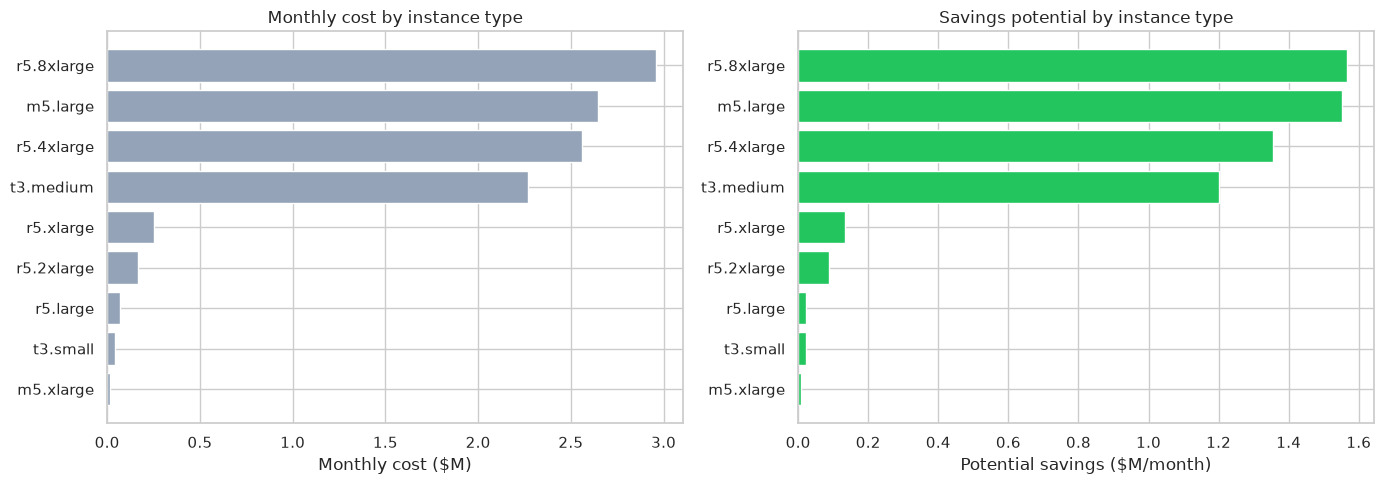

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(costs["ec2_type"], costs["monthly_cost"]/1e6, color="#94A3B8", edgecolor="white")
axes[0].set_xlabel("Monthly cost ($M)")
axes[0].set_title("Monthly cost by instance type")
axes[0].invert_yaxis()

axes[1].barh(costs["ec2_type"], costs["total_savings"]/1e6, color="#22C55E", edgecolor="white")
axes[1].set_xlabel("Potential savings ($M/month)")
axes[1].set_title("Savings potential by instance type")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../reports/figures/cost_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Cost vs waste waterfall

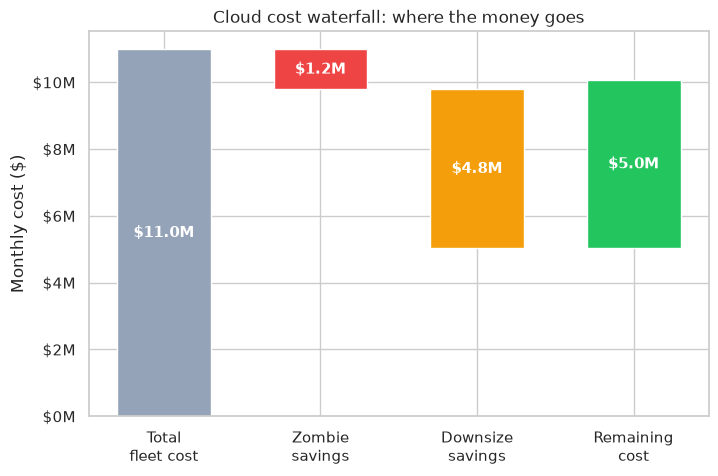

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
categories = ["Total\nfleet cost", "Zombie\nsavings", "Downsize\nsavings", "Remaining\ncost"]
values = [total_cost, -costs["zombie_savings"].sum(), -costs["downsize_savings"].sum(), 
          total_cost - total_savings]
colors = ["#94A3B8", "#EF4444", "#F59E0B", "#22C55E"]

cumulative = [0]
for v in values[:-1]:
    cumulative.append(cumulative[-1] + v)

for i, (cat, val, col, bottom) in enumerate(zip(categories, values, colors, cumulative)):
    height = abs(val)
    base = bottom if val > 0 else bottom + val
    ax.bar(cat, height, bottom=base, color=col, edgecolor="white", width=0.6)
    ax.text(i, base + height/2, f"${abs(val)/1e6:.1f}M", ha="center", va="center", 
            fontweight="bold", color="white", fontsize=11)

ax.set_ylabel("Monthly cost ($)")
ax.set_title("Cloud cost waterfall: where the money goes")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
plt.savefig("../reports/figures/cost_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. The pitch number

> **"In a fleet of 123K VMs, 54% of the spend — $5.9M/month — is waste.  
> That's $71M/year that could be recovered by right-sizing and shutting down idle machines."**